# **California Housing**

## **Описание набора данных**

**California Housing** — набор данных о жилье в Калифорнии, собранный в 1990 году.

 В наборе 8 количественных признаков и целевая переменная — медианная стоимость жилья для районов Калифорнии, выраженная в сотнях тысяч долларов ($100,000).

Некоторые признаки набора:

MedInc — медианный доход в группе блоков;

HouseAge — медианный возраст дома в группе блоков;

AveRooms — среднее количество комнат в доме;

AveBedrms — среднее количество спален в доме;

Population — население группы блоков;

AveOccup — среднее количество членов семьи;

Latitude — широта группы блоков;

Longitude — долгота группы блоков.

##**Загрузка и подготовка данных**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [ ]:
## Загружаем датасет California housing
california = fetch_california_housing()

## Создаем dataframe
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

print("California Housing Dataset:")

## Выводим первые десять строк
df.head(10)

California Housing Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


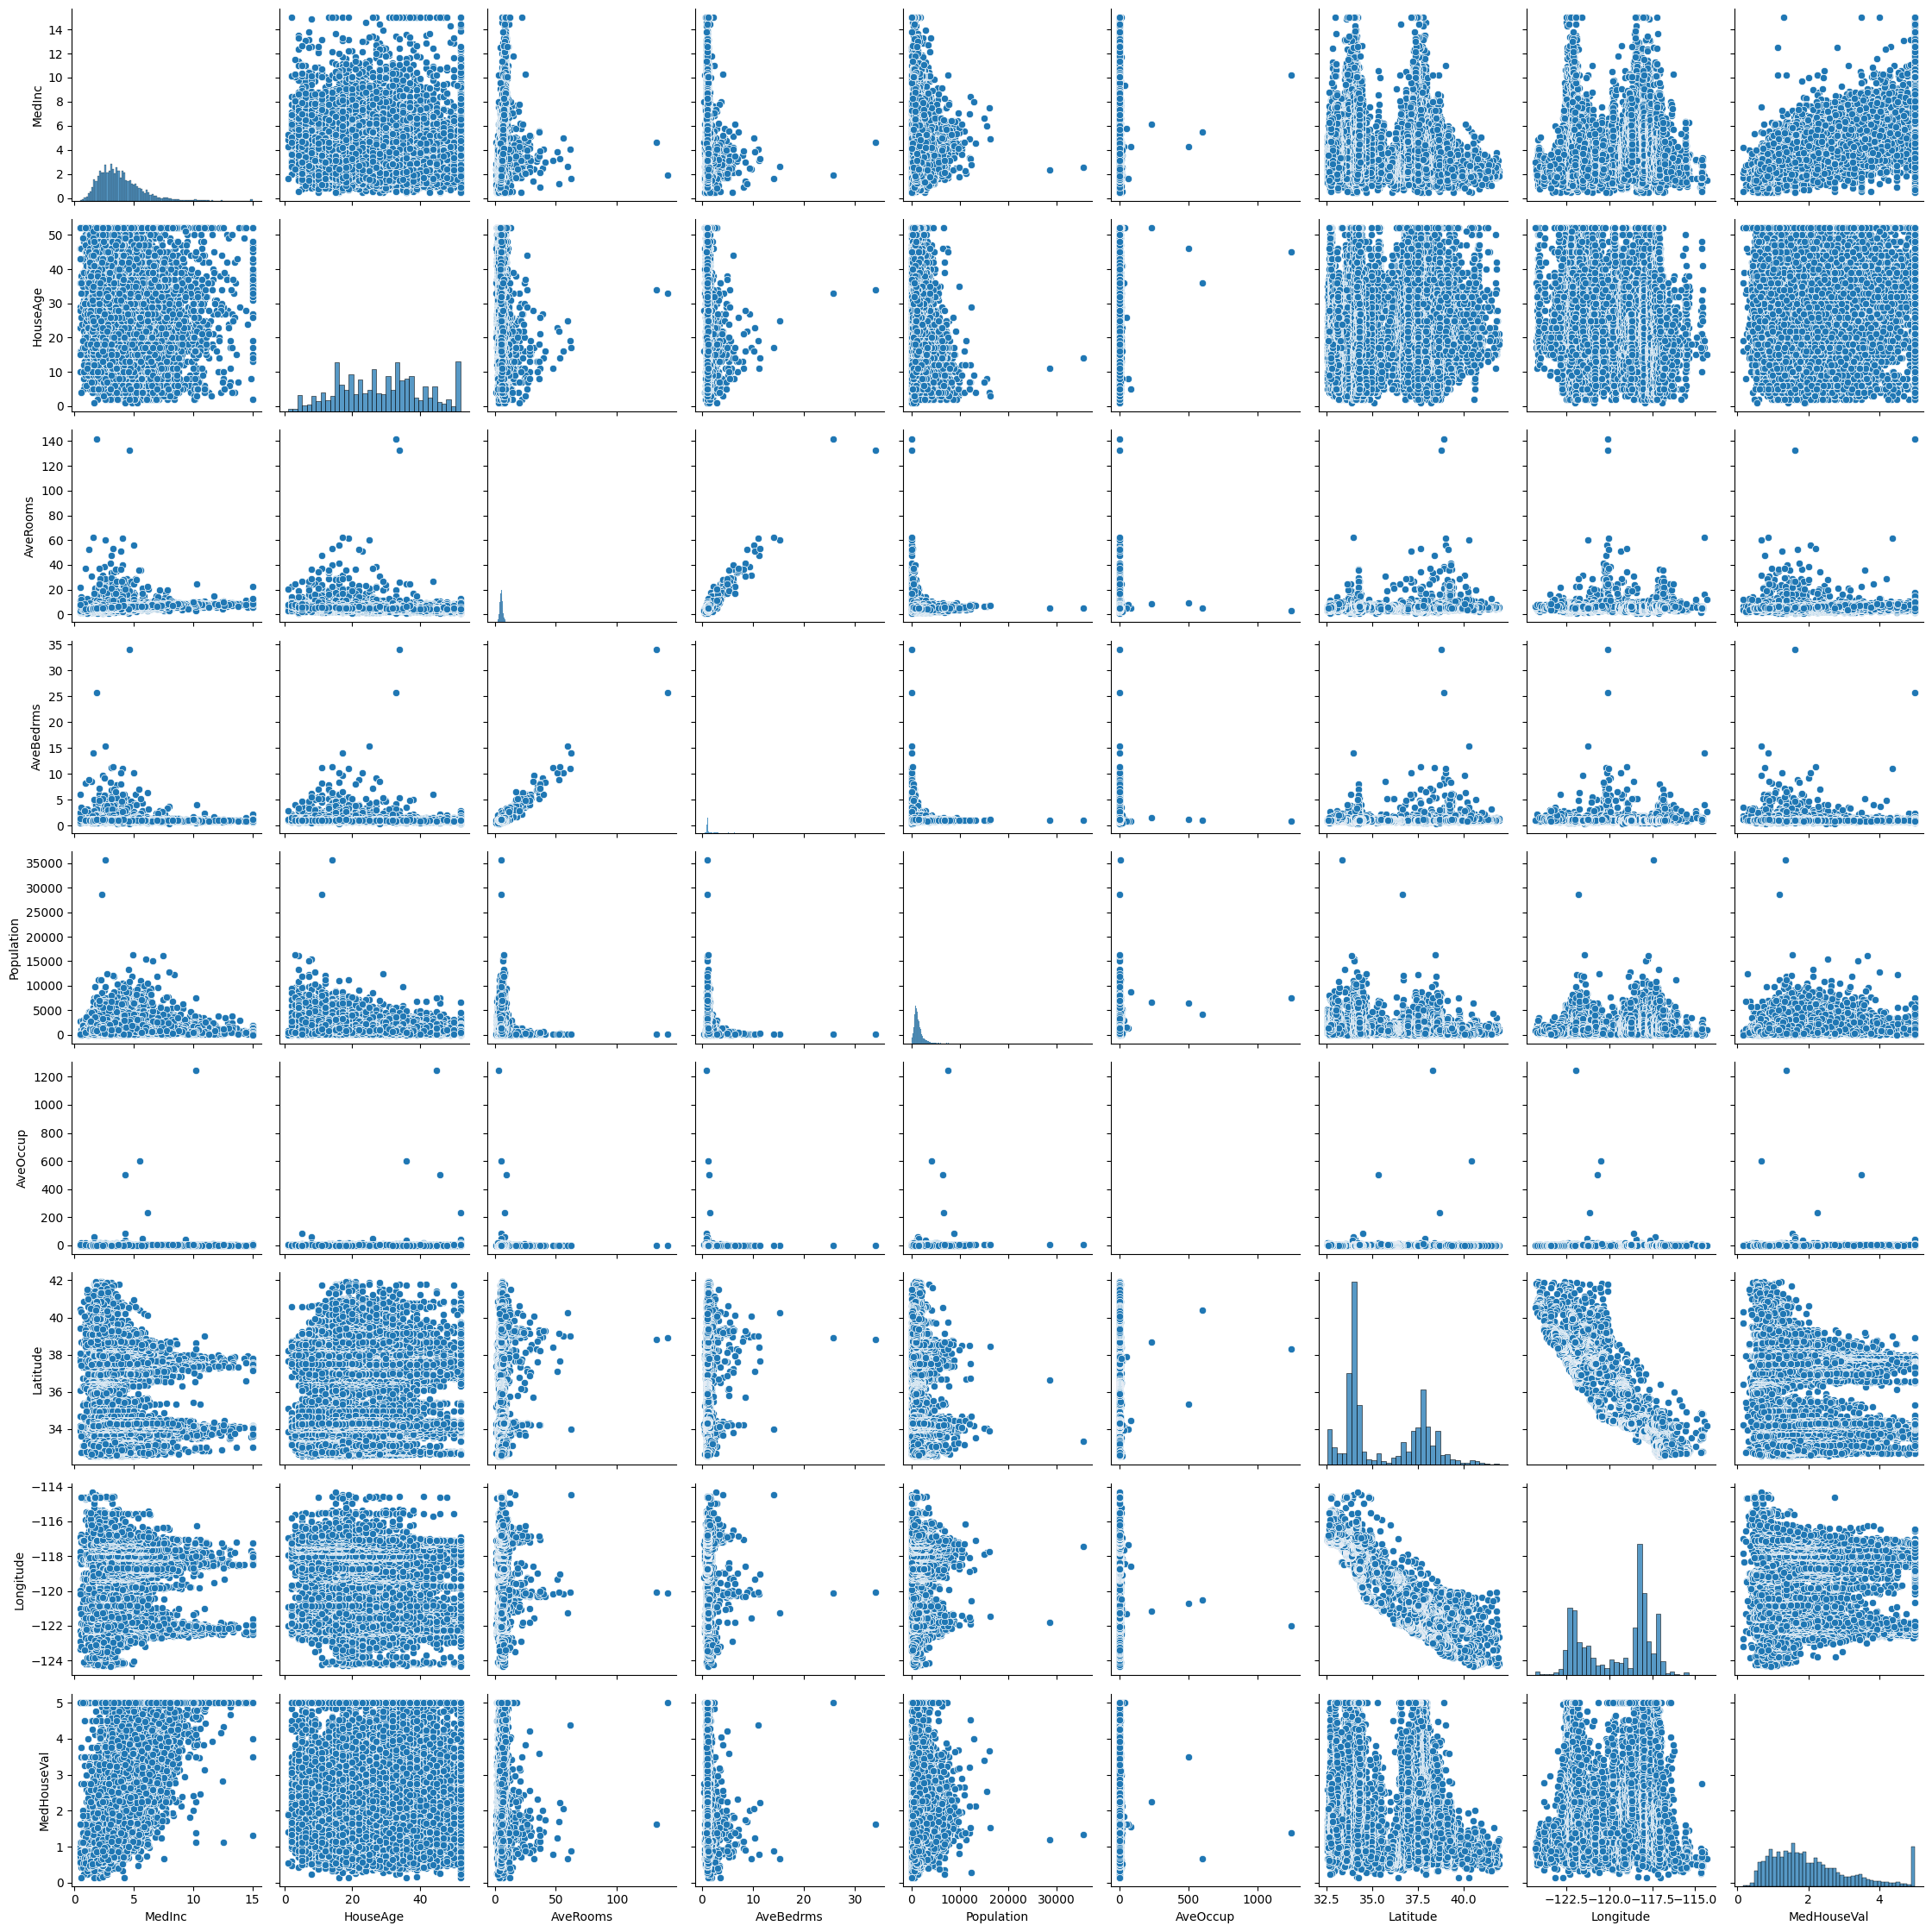

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(df, height=2.5)
plt.tight_layout()

In [ ]:
from sklearn.model_selection import train_test_split
## Prepare the data
#X = df.drop('MedHouseVal', axis=1)  ## Features (input variables)
X = pd.DataFrame(df['MedInc'])
X

,MedInc
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462
...,...
20635,1.5603
20636,2.5568
20637,1.7000
20638,1.8672


In [ ]:
y = df['MedHouseVal']  ## Target variable (what we want to predict)
y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


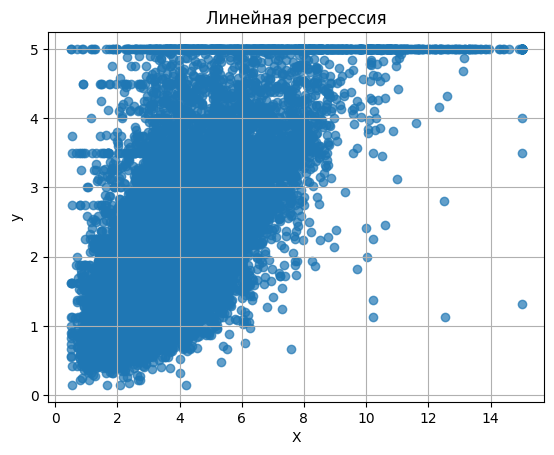

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X, y, alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Линейная регрессия")
plt.grid(True)
plt.show()

In [ ]:
## Split the data into training and testing sets
## test_size=0.2: Reserve 20% of data for testing, 80% for training
## random_state=42: Ensures reproducible splits (same result every run)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Print the shapes of the new datasets to confirm the split
print("\n--- Data Split ---")
print("X_train shape:", X_train.shape)  ## Training features
print("X_test shape:", X_test.shape)    ## Test features
print("y_train shape:", y_train.shape)  ## Training target values
print("y_test shape:", y_test.shape)    ## Test target values


--- Data Split ---
X_train shape: (16512, 1)
X_test shape: (4128, 1)
y_train shape: (16512,)
y_test shape: (4128,)


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Инициализация модели линейной регрессии
model = LinearRegression()

## Вывод модели для подтверждения ее создания
print("\n--- Model Initialized ---")
print(model)

# Обучение модели
model.fit(X_train, y_train)

# Выводим параметры модели
print("w0 (intercept):", model.intercept_)
print("w1 (coefficient):", model.coef_)

# Проверяем работу модели на тестовых данных
y_pred = model.predict(X_test) # предсказываем значения для тестовых данных

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")


--- Model Initialized ---
LinearRegression()
w0 (intercept): 0.4445972916907879
w1 (coefficient): [0.41933849]
MSE:  0.7091
RMSE: 0.8421
MAE:  0.6299
R^2:  0.4589


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


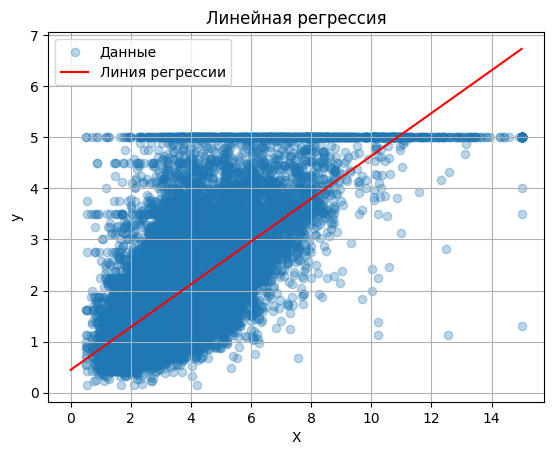

In [ ]:
plt.scatter(X, y, alpha=0.3, label="Данные")
X_line = np.linspace(0, X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color="red", label="Линия регрессии")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)
plt.show()

<Axes: >

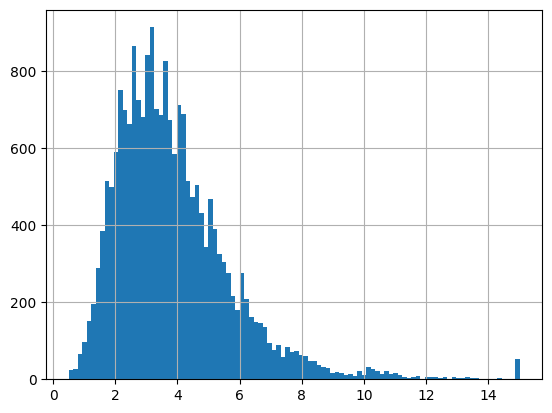

In [ ]:
df['MedInc'].hist(bins=100)

<Axes: >

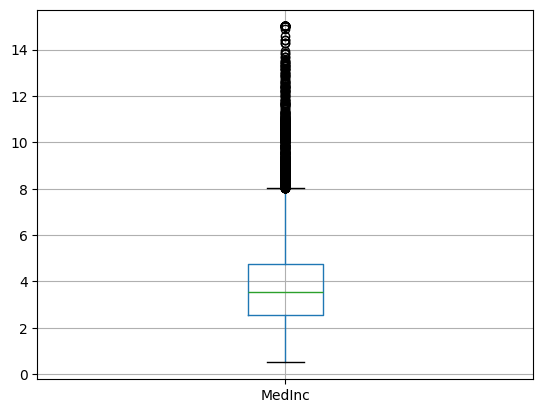

In [ ]:
df.boxplot(column='MedInc')

<Axes: >

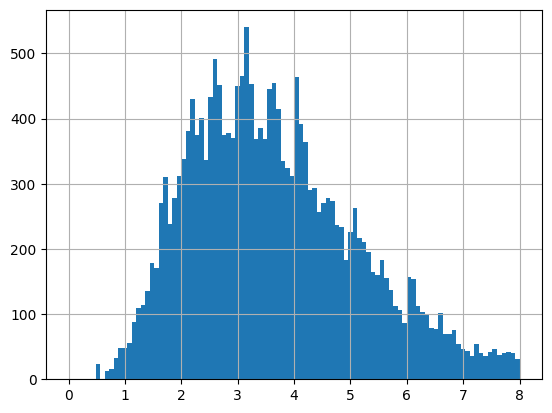

In [ ]:
df['MedInc'].hist(bins=100, range=(0,8))

In [ ]:
df1 = df.query("MedInc > 8")

In [ ]:
len(df1)/len(df)

0.03343023255813953

In [ ]:
df = df.query("MedInc < 8")

<Axes: >

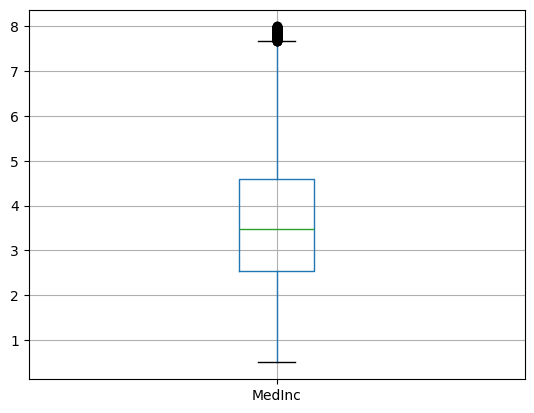

In [ ]:
df.boxplot(column='MedInc')

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Prepare the data
#X = df.drop('MedHouseVal', axis=1)  ## Features (input variables)
X = pd.DataFrame(df['MedInc'])
y = df['MedHouseVal']  ## Target variable (what we want to predict)

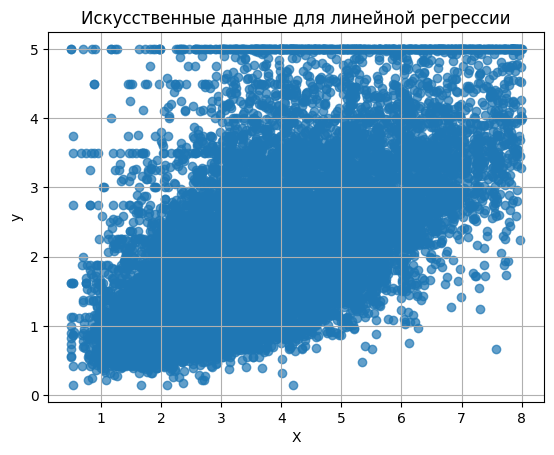

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X, y, alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Искусственные данные для линейной регрессии")
plt.grid(True)
plt.show()

# **Построение модели**

In [ ]:
## Split the data into training and testing sets
## test_size=0.2: Reserve 20% of data for testing, 80% for training
## random_state=42: Ensures reproducible splits (same result every run)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Print the shapes of the new datasets to confirm the split
print("\n--- Data Split ---")
print("X_train shape:", X_train.shape)  ## Training features
print("X_test shape:", X_test.shape)    ## Test features
print("y_train shape:", y_train.shape)  ## Training target values
print("y_test shape:", y_test.shape)    ## Test target values


--- Data Split ---
X_train shape: (15959, 1)
X_test shape: (3990, 1)
y_train shape: (15959,)
y_test shape: (3990,)


In [ ]:
## Инициализация модели линейной регрессии
model = LinearRegression()

## Вывод модели для подтверждения ее создания
print("\n--- Model Initialized ---")
print(model)

# Обучение модели
model.fit(X_train, y_train)

# Выводим параметры модели
print("w0 (intercept):", model.intercept_)
print("w1 (coefficient):", model.coef_)

# Проверяем работу модели на тестовых данных
y_pred = model.predict(X_test) # предсказываем значения для тестовых данных

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")


--- Model Initialized ---
LinearRegression()
w0 (intercept): 0.3464659563865613
w1 (coefficient): [0.44488765]
MSE:  0.7480
RMSE: 0.8649
MAE:  0.6410
R^2:  0.3708


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


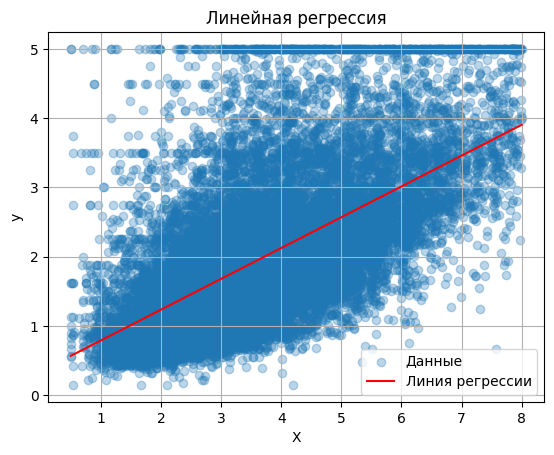

In [ ]:
plt.scatter(X, y, alpha=0.3, label="Данные")
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color="red", label="Линия регрессии")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)
plt.show()

<Axes: >

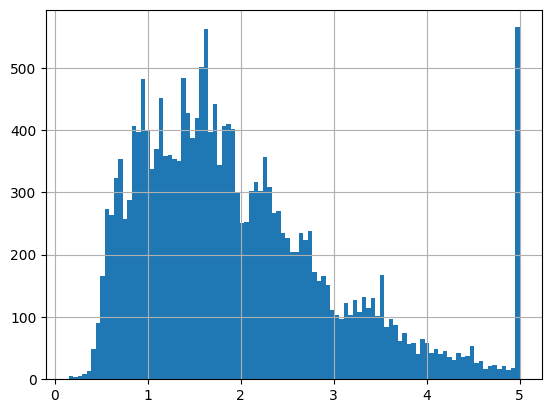

In [ ]:
df['MedHouseVal'].hist(bins=100)

<Axes: >

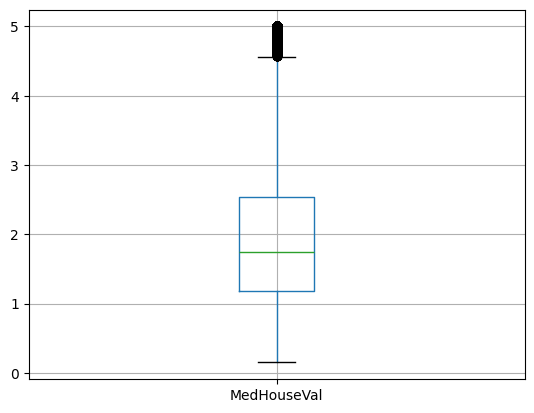

In [ ]:
df.boxplot(column='MedHouseVal')

In [ ]:
df1 = df.query("MedHouseVal > 4.5")

In [ ]:
len(df1)/len(df)

0.03794676424883453

In [ ]:
df = df.query("MedHouseVal < 4")
len(df)

18741

<Axes: >

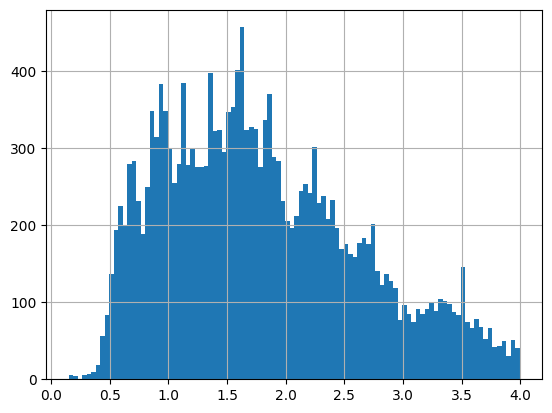

In [ ]:
df['MedHouseVal'].hist(bins=100)

<Axes: >

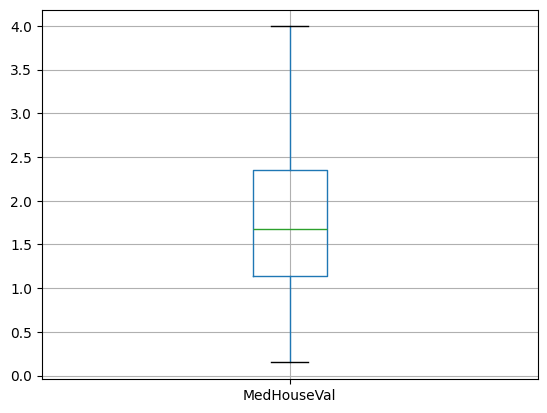

In [ ]:
df.boxplot(column='MedHouseVal')

In [ ]:
X = pd.DataFrame(df['MedInc'])
y = df['MedHouseVal']  ## Target variable (what we want to predict)

In [ ]:
## Split the data into training and testing sets
## test_size=0.2: Reserve 20% of data for testing, 80% for training
## random_state=42: Ensures reproducible splits (same result every run)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Print the shapes of the new datasets to confirm the split
print("\n--- Data Split ---")
print("X_train shape:", X_train.shape)  ## Training features
print("X_test shape:", X_test.shape)    ## Test features
print("y_train shape:", y_train.shape)  ## Training target values
print("y_test shape:", y_test.shape)    ## Test target values


--- Data Split ---
X_train shape: (14992, 1)
X_test shape: (3749, 1)
y_train shape: (14992,)
y_test shape: (3749,)


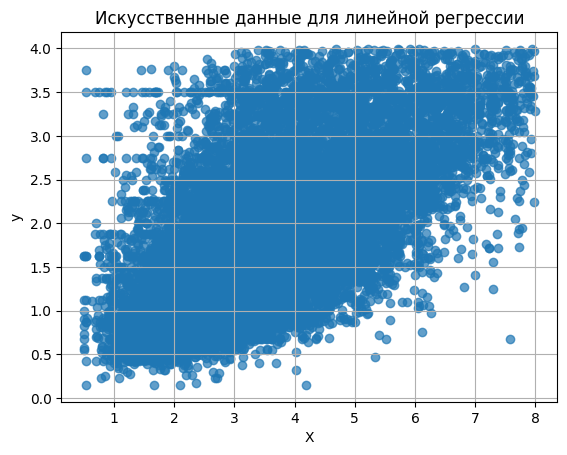

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X, y, alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Искусственные данные для линейной регрессии")
plt.grid(True)
plt.show()

## **Линейная регрессия**

In [ ]:
## Инициализация модели линейной регрессии
model = LinearRegression()

## Вывод модели для подтверждения ее создания
print("\n--- Model Initialized ---")
print(model)

# Обучение модели
model.fit(X_train, y_train)

# Выводим параметры модели
print("w0 (intercept):", model.intercept_)
print("w1 (coefficient):", model.coef_)

# Проверяем работу модели на тестовых данных
y_pred = model.predict(X_test) # предсказываем значения для тестовых данных

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")


--- Model Initialized ---
LinearRegression()
w0 (intercept): 0.4925533262600068
w1 (coefficient): [0.37036823]
MSE:  0.4138
RMSE: 0.6433
MAE:  0.5057
R^2:  0.4080


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


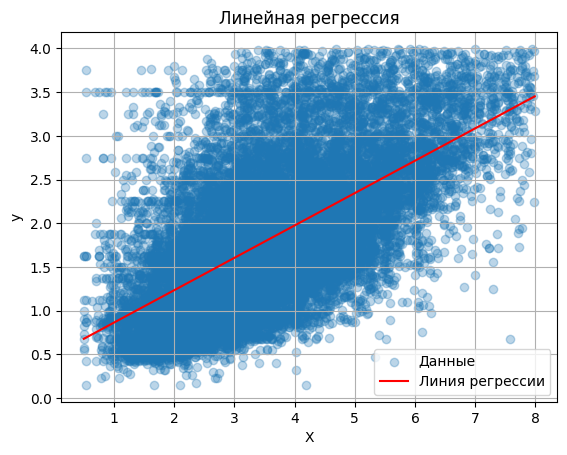

In [ ]:
plt.scatter(X, y, alpha=0.3, label="Данные")
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color="red", label="Линия регрессии")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Линейная регрессия")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X_train, y_train, alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Искусственные данные для линейной регрессии")
plt.grid(True)
plt.show()

## **Множественная регрессия**

In [ ]:
## Загружаем датасет California housing
california = fetch_california_housing()

## Создаем dataframe
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

print("California Housing Dataset:")

## Выводим первые десять строк
df.head(10)


California Housing Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [ ]:
X = df.drop('MedHouseVal', axis = 1)
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
y = df['MedHouseVal']  ## Target variable (what we want to predict)
y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [ ]:
## Split the data into training and testing sets
## test_size=0.2: Reserve 20% of data for testing, 80% for training
## random_state=42: Ensures reproducible splits (same result every run)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Print the shapes of the new datasets to confirm the split
print("\n--- Data Split ---")
print("X_train shape:", X_train.shape)  ## Training features
print("X_test shape:", X_test.shape)    ## Test features
print("y_train shape:", y_train.shape)  ## Training target values
print("y_test shape:", y_test.shape)    ## Test target values


--- Data Split ---
X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


In [ ]:
## Инициализация модели линейной регрессии
model = LinearRegression()

## Вывод модели для подтверждения ее создания
print("\n--- Model Initialized ---")
print(model)

# Обучение модели
model.fit(X_train, y_train)

# Выводим параметры модели
print("w0 (intercept):", model.intercept_)
print("w1 (coefficient):", model.coef_)

# Проверяем работу модели на тестовых данных
y_pred = model.predict(X_test) # предсказываем значения для тестовых данных

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")


--- Model Initialized ---
LinearRegression()
w0 (intercept): -37.02327770606409
w1 (coefficient): [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
MSE:  0.5559
RMSE: 0.7456
MAE:  0.5332
R^2:  0.5758


# **Масштабирование признаков (нормализация)**

StandardScaler — это класс из библиотеки scikit-learn, который стандартизирует признаки, вычитая среднее значение и масштабируя до единичной дисперсии. Проще говоря, он приводит данные к стандартному нормальному распределению с центром в нуле и стандартным отклонением, равным единице.

Зачем это делать? Представьте себе, что вы анализируете данные о недвижимости, где один признак — площадь в квадратных метрах (от 30 до 500), а другой — количество комнат (от 1 до 10). Без нормализации алгоритм будет «думать», что площадь важнее, просто потому что числа больше.

StandardScaler – класс Scikit-learn, реализующий нормализацию данных по формуле

$x_{i, norm} =- \frac{x_i-\mu}{\sigma},$

где $x_{i, norm}$ -- нормалихованный элемент признака,

$x_i$ -- исходный элемент признака,

$\mu$ -- среднее арифметическое,

$\sigma$ -- стандартное отклонение.

Вычисление Среднего арифметического (Mean) и Стандартного отклонения (Standard Deviation) происходят независимо для каждого признака. Затем эти Статистики (Statistics) сохраняются для последующего использования с помощью преобразования.

Рассмотрим пример.

У нас есть признак "годовой доход" с значениями [35000, 45000, 55000, 65000, 200000]. Его среднее составляет 80000, а стандартное отклонение примерно 64087. После применения StandardScaler мы получим:

z1 = (35000 – 80000) / 64087 ≈ -0.70

z2 = (45000 – 80000) / 64087 ≈ -0.55

z3 = (55000 – 80000) / 64087 ≈ -0.39

z4 = (65000 – 80000) / 64087 ≈ -0.23

z5 = (200000 – 80000) / 64087 ≈ 1.87


Стандартизация набора данных является общим требованием для многих Алгоритмов (Algorithm) Машинного обучения (ML): они могут "вести себя плохо", если отдельные признаки не выглядят как нормально распределенные данные (например, по Гауссу с нулевым средним и единичной дисперсией).

| Алгоритм | Чувствительность к масштабу | Необходимость StandardScaler |
| -------- | --------------------------- | ---------------------------- |
| K-Means	 | Высокая                     | Критическая                  |
| Нейронные сети|Высокая|Критическая|
|SVM|Высокая|Критическая|
|KNN|Высокая|Критическая|
|Линейная регрессия|Средняя|	Рекомендуемая|
|Решающие деревья	|Низкая	|Опциональная |
|Random Forest|	Низкая|	Опциональная|

Теперь наш признак имеет среднее 0 и стандартное отклонение 1. Выброс (200000) превратился в 1.87, что все еще выше нормы, но уже не так драматично искажает масштаб.

В контексте scikit-learn, StandardScaler реализует именно эту формулу. Когда мы вызываем метод fit(), класс вычисляет μ и σ для каждого признака в наборе данных и сохраняет их во внутренних атрибутах. Затем метод transform() применяет формулу к каждому значению.

Важно понимать, что StandardScaler обрабатывает каждую колонку (признак) независимо от других. Это означает, что:

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Создаем образец данных
data = np.array([[35000, 5],
[45000, 7],
[55000, 9],
[65000, 11],
[200000, 13]])

# Инициализируем и применяем StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

print("Оригинальные данные:")
print(data)
print("\nНормализованные данные:")
print(scaled_data)

Оригинальные данные:
[[ 35000      5]
 [ 45000      7]
 [ 55000      9]
 [ 65000     11]
 [200000     13]]

Нормализованные данные:
[[-0.73979544 -1.41421356]
 [-0.57539646 -0.70710678]
 [-0.41099747  0.        ]
 [-0.24659848  0.70710678]
 [ 1.97278785  1.41421356]]


 после нормализации числовые признаки стали сопоставимыми по масштабу, несмотря на огромную разницу в исходных значениях.

В некоторых ситуациях бывает полезно сохранить параметры нормализации для последующего применения к новым данным (например, для тестового набора или при предсказании). В этом случае можно использовать методы:

In [ ]:
# Сохранение параметров нормализации
means = scaler.mean_
vars = scaler.var_

# Применение тех же параметров к новым данным
new_data = np.array([[50000, 8]])
scaled_new_data = scaler.transform(new_data)

## **Линейная регрессия с нормализацией данных**

In [ ]:
## Загружаем датасет California housing
california = fetch_california_housing()

## Создаем dataframe
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

print("California Housing Dataset:")

## Выводим первые десять строк
df.head(10)

X = pd.DataFrame(df['MedInc'])
y = df['MedHouseVal']  ## Target variable (what we want to predict)

California Housing Dataset:


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # обучаем скалер на train
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

MSE:  0.7091
RMSE: 0.7456
MAE:  0.5332
R^2:  0.4589


## **Множественная линейная регрессия с нормализацией данных**

In [ ]:
## Загружаем датасет California housing
california = fetch_california_housing()

## Создаем dataframe
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

print("California Housing Dataset:")

X = df.drop('MedHouseVal', axis = 1)
y = df['MedHouseVal']  ## Target variable (what we want to predict)

California Housing Dataset:


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # обучаем скалер на train
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")


MSE:  0.5559
RMSE: 0.7456
MAE:  0.5332
R^2:  0.5758


# **Конвейер машинного обучения (Pipeline)**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline

## Загружаем датасет California housing
california = fetch_california_housing()

## Создаем dataframe
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

print("California Housing Dataset:")

X = df.drop('MedHouseVal', axis = 1)
y = df['MedHouseVal']  ## Target variable (what we want to predict)

# Создание и обучение пайплайна с StandardScaler
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Print the shapes of the new datasets to confirm the split
print("\n--- Data Split ---")
print("X_train shape:", X_train.shape)  ## Training features
print("X_test shape:", X_test.shape)    ## Test features
print("y_train shape:", y_train.shape)  ## Training target values
print("y_test shape:", y_test.shape)    ## Test target values

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R^2:  {r2:.4f}")

California Housing Dataset:

--- Data Split ---
X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)
MSE:  0.5559
RMSE: 0.7456
MAE:  0.5332
R^2:  0.5758


Использование Pipeline имеет ряд преимуществ:

Автоматическое применение одинаковых преобразований к обучающей и тестовой выборкам

Предотвращение утечки данных между этапами

Упрощение кода и повышение читаемости

Возможность проведения кросс-валидации над всей цепочкой преобразований

# Geopandas

In [ ]:

from sklearn.datasets import fetch_california_housing
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Загрузка данных
california_housing = fetch_california_housing(as_frame=True)
df = pd.concat([california_housing.data, california_housing.target], axis=1)

In [ ]:
from shapely.geometry import Point

# Создание геометрии
df['geometry'] = df.apply(lambda row: Point(row.Longitude, row.Latitude), axis=1)

# Преобразование в GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")  # WGS84

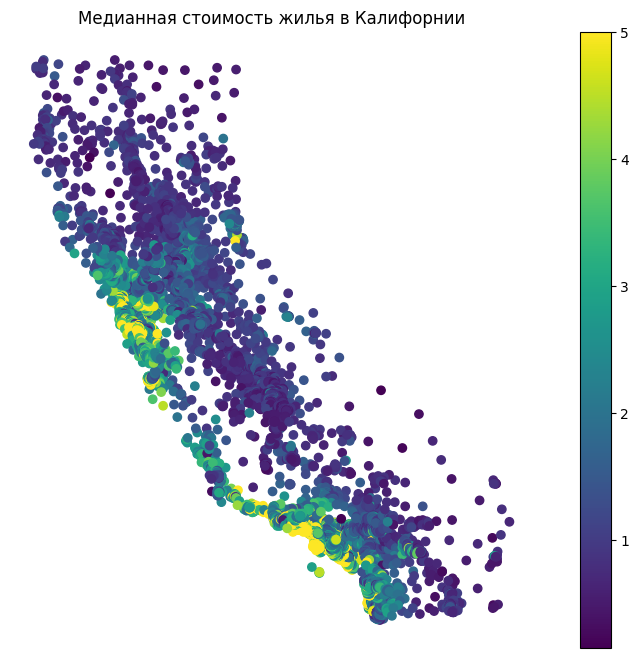

In [ ]:

# Базовая карта
ax = gdf.plot(column='MedHouseVal', cmap='viridis', legend=True, figsize=(12, 8))

# Настройка отображения
ax.set_title('Медианная стоимость жилья в Калифорнии')
ax.set_axis_off()  # Убрать оси

# Показать карту
plt.show()

In [ ]:
!pip install contextily

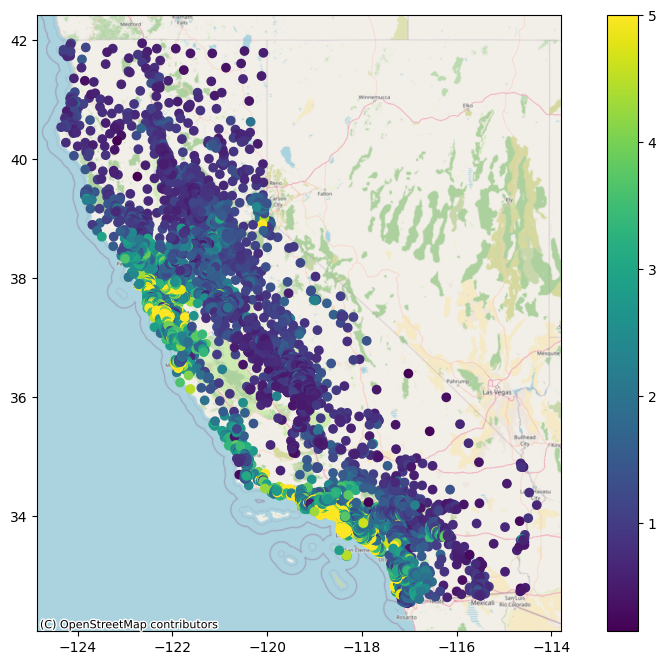

In [ ]:
import contextily as cx

ax = gdf.plot(column='MedHouseVal', cmap='viridis', legend=True, figsize=(12, 8))
cx.add_basemap(ax, crs=gdf.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)
plt.show()

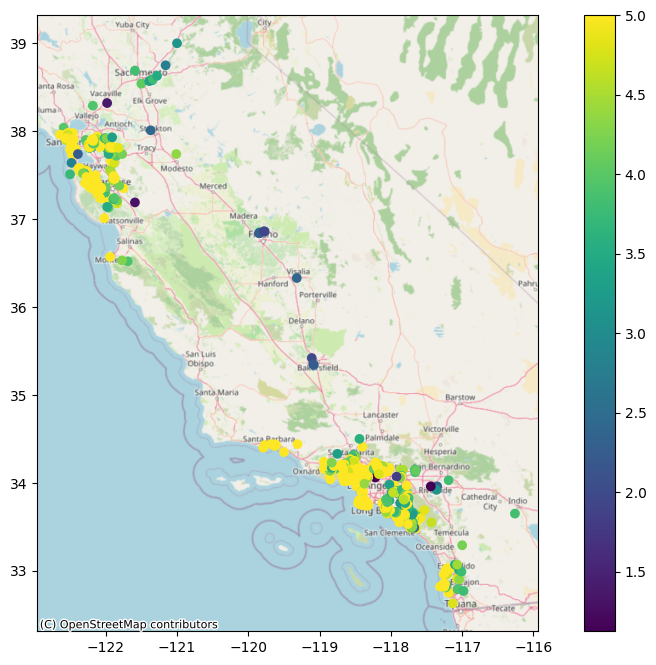

In [ ]:
filtered_gdf = gdf[gdf['MedInc'] > 8]
ax = filtered_gdf.plot(column='MedHouseVal', cmap='viridis', legend=True, figsize=(12, 8))
cx.add_basemap(ax, crs=gdf.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)
plt.show()

In [ ]:
import geopandas as gpd

# Предположим, gdf уже создан
interactive_map = gdf.explore(marker_type='marker', column='MedHouseVal', cmap='viridis', legend=True, tiles="CartoDB Positron")
interactive_map.show_in_browser()
outfp = "california_housing_map.html"
interactive_map.save(outfp)

Your map should have been opened in your browser automatically.
Press ctrl+c to return.


In [ ]:
!pip install folium

In [ ]:
import folium

# Import folium MarkerCluster plugin
from folium.plugins import MarkerCluster
# Import folium MousePosition plugin
from folium.plugins import MousePosition
# Import folium DivIcon plugin
from folium.features import DivIcon

print('Folium installed and imported!')

Folium installed and imported!


In [ ]:
import folium
from sklearn.datasets import fetch_california_housing
import pandas as pd

In [ ]:
# Загрузка данных
california_housing = fetch_california_housing(as_frame=True)
df = pd.concat([california_housing.data, california_housing.target], axis=1)[:1000]

# Переименование целевого столбца для ясности
df = df.rename(columns={'MedHouseVal': 'median_house_value'})

In [ ]:
# Создание карты с центром в Калифорнии
m = folium.Map(location=[36.7783, -119.4179], zoom_start=6)

# Добавление маркеров
for idx, row in df.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Median value: ${row['median_house_value'] * 100_000:.0f}",
        tooltip=f"Income: ${row['MedInc'] * 10_000:.0f}"
    ).add_to(m)

# Сохранение в HTML-файл
m.save('california_housing_map.html')